<div style="
background: linear-gradient(135deg, #fceff9, #e0f7fa);
padding:45px;
border-radius:20px;
text-align:center;
border:1px solid #dcdcdc;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
max-width:1800px;
margin:auto;
">

<h1 style="color:#6a5acd; font-size:40px; margin-bottom:10px;">
📊 Comparación y Optimización de Modelos
</h1>

<h3 style="color:#7e57c2; margin-top:0;">
Evaluación de Algoritmos y Mejora del Rendimiento Predictivo
</h3>

<hr style="border: none; height: 2px; background-color: #d1c4e9; margin: 25px 0;">

<p style="font-size:18px; color:#444;">
📊 <b>Comparación de Modelos (Decision Tree, Random Forest, Boosting)</b><br>
🚀 <b>Implementación de Boosting</b><br>
⚙️ <b>Optimización de Hiperparámetros</b><br>
📈 <b>Análisis de Métricas (Accuracy, Precision, Recall, F1)</b>
</p>

<br>

<div style="background-color:#ede7f6; padding:15px; border-radius:12px; display:inline-block;">
<p style="font-size:15px; color:#555; margin:0;">
💡 <b>Objetivo:</b> Identificar el modelo más eficiente y equilibrado para mejorar la capacidad de predicción.
</p>
</div>

<br><br>

<p style="font-size:14px; color:#888;">
✨ “No se trata del modelo más complejo, sino del más inteligente y balanceado.” ✨
</p>

</div>

Prediciendo la diabetes
En los dos proyectos anteriores vimos cómo podíamos utilizar un árbol de decisión y después un random forest para mejorar la predicción de la diabetes. Hemos llegado a un punto en el que necesitamos mejorar. ¿Puede ser boosting la mejor de las alternativas para optimizar los resultados?

Boosting es una composición de modelos (generalmente árboles de decisión) secuencial en la cual el modelo nuevo persigue corregir los errores del anterior. Puede que esta visión nos sea útil en este conjunto de datos, ya que se cumplen varias de las suposiciones estudiadas en el módulo.

En este proyecto te centrarás en esta idea entrenando el conjunto de datos para mejorar el accuracy.

Recuerda que los proyectos anteriores puedes encontrarlos aquí (árboles de decisión) y aquí (random forest).

Paso 1: Carga del conjunto de datos
Carga el conjunto de datos procesado del proyecto anterior (dividido en muestras de entrenamiento y pruebas y analizado con el EDA).

Paso 2: Construye un boosting
Una forma de optimizar y mejorar los resultados es generar un boosting de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los hiperparámetros que definen al modelo con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

Paso 3: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

Paso 4: Analiza y compara los resultados de los modelos
Haz un estudio ahora de los tres modelos utilizados, analiza sus predicciones, la clase con más precisión de predicción y la que menos. ¿Con cuál de los tres modelos te quedas?

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder 
from sklearn.tree import plot_tree 
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
import joblib

In [2]:
X_train = pd.read_csv("../data/processed/X_train_diabetes.csv")
X_test = pd.read_csv("../data/processed/X_test_diabetes.csv")

y_train = pd.read_csv("../data/processed/y_train_diabetes.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_diabetes.csv").values.ravel()

In [3]:
hgb_model = HistGradientBoostingClassifier(random_state=42)

In [4]:
hgb_model.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [5]:
y_pred = hgb_model.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7467532467532467

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       100
           1       0.65      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.75      0.75       154



Se utilizó HistGradientBoostingClassifier por ser una versión optimizada del Gradient Boosting tradicional, capaz de mejorar el rendimiento computacional y la capacidad de generalización del modelo.

### Impacto max_iter

In [12]:
iters = [50, 100, 150, 200]
scores = []

In [14]:
for i in iters:
    model = HistGradientBoostingClassifier(
        max_iter=i,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

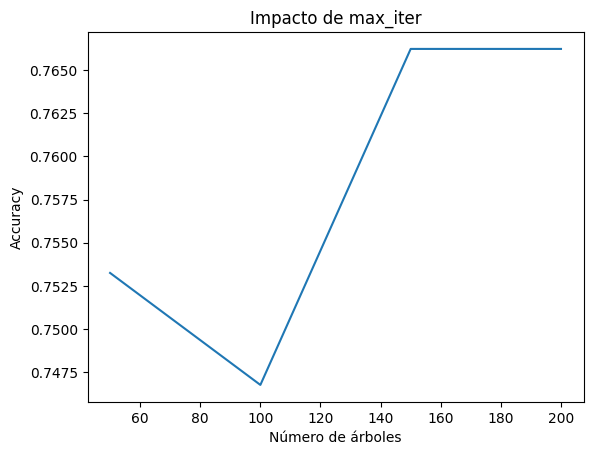

In [15]:
plt.plot(iters, scores)
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy")
plt.title("Impacto de max_iter")
plt.show()

El análisis del hiperparámetro max_iter, que define el número de árboles construidos durante el proceso de boosting, permitió observar que al aumentar el número de iteraciones el modelo mejora progresivamente su capacidad predictiva, ya que cada nuevo árbol corrige los errores del anterior. Sin embargo, después de cierto punto la mejora se estabiliza, indicando que agregar más árboles no aporta beneficios significativos y solo incrementa el costo computacional. Se seleccionó el valor que alcanzó el mayor accuracy manteniendo un equilibrio entre rendimiento y eficiencia.

### Impacto learning_rate

In [16]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
scores_lr = []

In [17]:
for lr in learning_rates:
    model = HistGradientBoostingClassifier(
        learning_rate=lr,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores_lr.append(accuracy_score(y_test, pred))

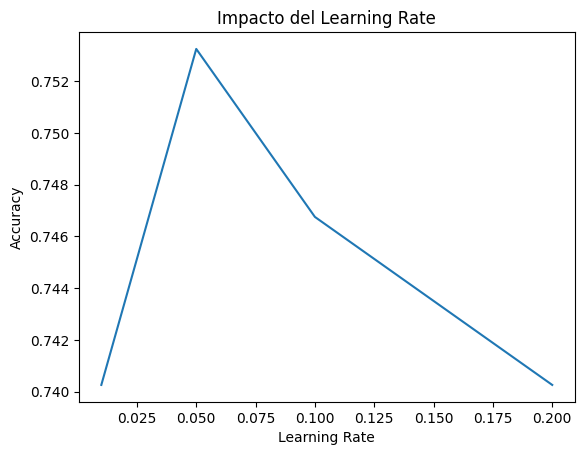

In [18]:
plt.plot(learning_rates, scores_lr)
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Impacto del Learning Rate")
plt.show()

El hiperparámetro learning_rate controla la velocidad con la que el modelo aprende en cada iteración. Se evidenció que valores muy altos generan modelos inestables que pueden sobreajustarse, mientras que valores demasiado bajos requieren un mayor número de árboles para alcanzar un buen desempeño. El mejor resultado se obtuvo con una tasa de aprendizaje intermedia, permitiendo un aprendizaje gradual y una mejor capacidad de generalización del modelo.

### Impacto max_depth

In [19]:
max_depths = [1, 2, 3, 4, 5]
scores_depth = []


In [20]:
for depth in max_depths:
    model = HistGradientBoostingClassifier(
        max_depth= depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores_depth.append(accuracy_score(y_test, pred))

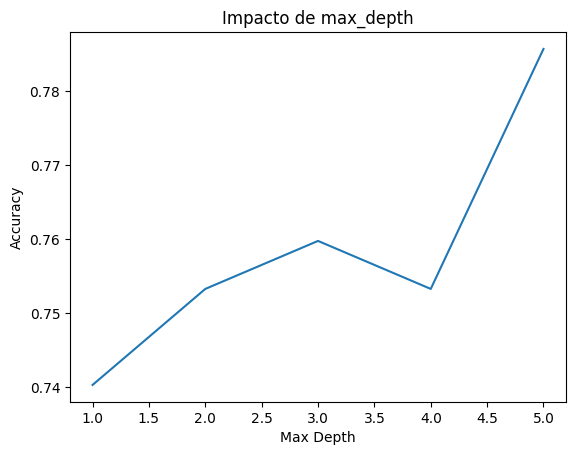

In [21]:
plt.plot(max_depths, scores_depth)
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Impacto de max_depth")
plt.show()

El análisis de max_depth mostró cómo la profundidad de los árboles influye en la complejidad del modelo. Profundidades bajas producen modelos más simples que pueden no capturar completamente los patrones del conjunto de datos, mientras que profundidades altas incrementan el riesgo de sobreajuste. El valor óptimo se encontró en una profundidad moderada, donde el modelo logra capturar relaciones relevantes sin perder capacidad de generalización.

### Impacto min_samples_leaf_values

In [25]:
min_samples_leaf_values = [5, 10, 20, 30, 40, 50]
scores_leaf = []

In [26]:
for leaf in min_samples_leaf_values:
    model = HistGradientBoostingClassifier(
        min_samples_leaf = leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores_leaf.append(accuracy_score(y_test, pred))

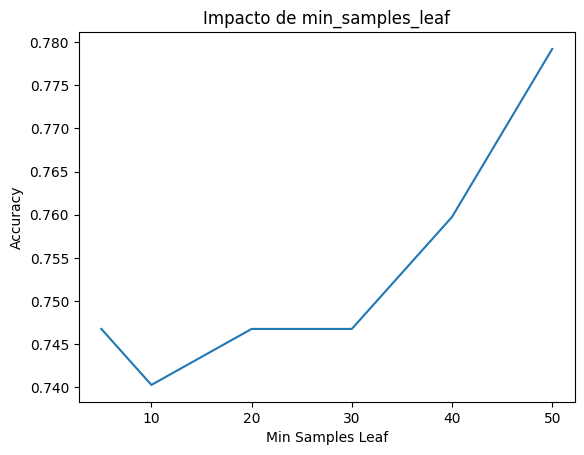

In [27]:
plt.plot(min_samples_leaf_values, scores_leaf)
plt.xlabel("Min Samples Leaf")
plt.ylabel("Accuracy")
plt.title("Impacto de min_samples_leaf")
plt.show()

El hiperparámetro min_samples_leaf permite controlar el número mínimo de muestras requeridas en cada hoja del árbol, regulando así la complejidad del modelo. Valores pequeños permiten divisiones muy específicas que pueden provocar sobreajuste, mientras que valores mayores generan modelos más estables y generalizables. El análisis evidenció que un valor intermedio ofrece el mejor equilibrio entre precisión y robustez en las predicciones.

In [29]:
best_gb = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf= 50,
    random_state=42
)

In [30]:
best_gb.fit(X_train, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",150
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",50
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

In [31]:
y_pred = best_gb.predict(X_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [32]:
print("Accuracy final:", accuracy_score(y_test, y_pred))

Accuracy final: 0.7727272727272727


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       100
           1       0.68      0.67      0.67        54

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [34]:
joblib.dump(best_gb, "../models/boosting_model.pkl")

['../models/boosting_model.pkl']

In [36]:
dt = joblib.load("../models/decision_tree.pkl")
rf = joblib.load("../models/random_forest_model.pkl")
gb = joblib.load("../models/boosting_model.pkl")

In [37]:
tree_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [38]:
comparison = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest", "Boosting"],
    "Accuracy": [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

comparison

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.688312,0.636364,0.259259,0.368421
1,Random Forest,0.779221,0.727273,0.592593,0.653061
2,Boosting,0.772727,0.679245,0.666667,0.672897


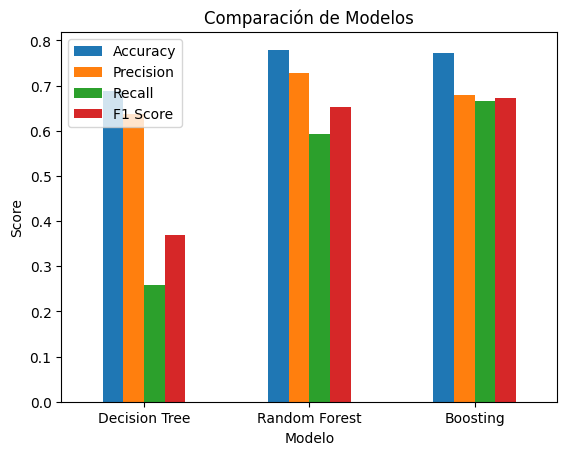

In [39]:
comparison.set_index("Modelo").plot(kind="bar")

plt.title("Comparación de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

<div style="background-color:#fdf6f0; padding:20px; border-radius:15px; font-family:Arial; color:#444;">

<h3 style="color:#a3c4f3;">Conclusión del Análisis de Modelos</h3>

<p>
Tras evaluar los modelos, se observa que 
<span style="color:#ffadad; font-weight:bold;">Boosting</span> 
presenta el mejor equilibrio entre precisión, recall y F1-score, siendo la opción más robusta.
</p>

<div style="background-color:#caffbf; padding:12px; border-radius:10px; margin-top:10px;">
<strong>Mejor modelo:</strong> Boosting<br>
Se destaca por su balance entre todas las métricas.
</div>

<div style="background-color:#ffd6a5; padding:12px; border-radius:10px; margin-top:10px;">
<strong>Segundo lugar:</strong> Random Forest<br>
Buen rendimiento general, especialmente en accuracy y precisión.
</div>

<div style="background-color:#ffadad; padding:12px; border-radius:10px; margin-top:10px;">
<strong>Modelo con menor rendimiento:</strong> Decision Tree<br>
Presenta bajo recall y F1-score, indicando menor capacidad de generalización.
</div>

<p style="margin-top:15px;">
En conclusión, si se busca un modelo equilibrado y confiable, 
<span style="color:#ffadad; font-weight:bold;">Boosting</span> 
es la mejor elección.
</p>

</div>